In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [36]:
# --------------------- PRETRAIN ON STL-10 ---------------------
# STL-10 Dataset Transformation
stl_transform = transforms.Compose([
    transforms.Resize((96, 96)),  # STL-10 native size
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load STL-10 dataset
stl_dataset = datasets.STL10(root="./data", split="train", download=True, transform=stl_transform)

# Train-Val Split (80%-20%)
train_size = int(0.8 * len(stl_dataset))
val_size = len(stl_dataset) - train_size
stl_train, stl_val = random_split(stl_dataset, [train_size, val_size])

# Dataloaders
stl_train_loader = DataLoader(stl_train, batch_size=64, shuffle=True, num_workers=2)
stl_val_loader = DataLoader(stl_val, batch_size=64, shuffle=False, num_workers=2)


Files already downloaded and verified


In [35]:

# Define ResNet18 Model
model = models.resnet18(pretrained=False)  # No ImageNet weights
model.fc = nn.Linear(model.fc.in_features, 10)  # STL-10 has 10 classes
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [37]:
# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [51]:
# Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        # Training Accuracy
        train_acc = correct / total

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")

    return model

In [45]:
# Evaluation Function
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    print(classification_report(all_labels, all_preds))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

In [40]:
# Train on STL-10
model = train_model(model, stl_train_loader, stl_val_loader, criterion, optimizer, num_epochs=10)

# Save Pretrained Model
torch.save(model.state_dict(), "stl10_pretrained.pth")
print("Pre-trained STL-10 model saved!")

Epoch [1/10], Loss: 1.7059, Train Acc: 0.3463, Val Acc: 0.3990
Epoch [2/10], Loss: 1.4011, Train Acc: 0.4680, Val Acc: 0.4810
Epoch [3/10], Loss: 1.1844, Train Acc: 0.5613, Val Acc: 0.5220
Epoch [4/10], Loss: 1.0264, Train Acc: 0.6262, Val Acc: 0.5050
Epoch [5/10], Loss: 0.8406, Train Acc: 0.6970, Val Acc: 0.5550
Epoch [6/10], Loss: 0.6620, Train Acc: 0.7655, Val Acc: 0.4730
Epoch [7/10], Loss: 0.5015, Train Acc: 0.8263, Val Acc: 0.5690
Epoch [8/10], Loss: 0.3031, Train Acc: 0.8922, Val Acc: 0.5270
Epoch [9/10], Loss: 0.2007, Train Acc: 0.9293, Val Acc: 0.5780
Epoch [10/10], Loss: 0.2158, Train Acc: 0.9265, Val Acc: 0.5510
Pre-trained STL-10 model saved!


In [52]:
# --------------------- TRANSFER LEARNING TO MNIST ---------------------
# MNIST Transformation
mnist_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

# Load Pretrained Model for Transfer Learning
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load("stl10_pretrained.pth"))
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-52-6da963c25043>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

In [53]:
# --------------------- TASK 1 ---------------------
for param in model.parameters():
    param.requires_grad = False  # Freeze all layers

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("\nTraining Linear Layers Only:")
train_model(model, mnist_loader, mnist_loader, criterion, optimizer)




Training Linear Layers Only:
Epoch [1/10], Loss: 1.1002, Train Acc: 0.6863
Epoch [2/10], Loss: 0.5552, Train Acc: 0.8524
Epoch [3/10], Loss: 0.4336, Train Acc: 0.8845
Epoch [4/10], Loss: 0.3709, Train Acc: 0.9000
Epoch [5/10], Loss: 0.3297, Train Acc: 0.9102
Epoch [6/10], Loss: 0.3016, Train Acc: 0.9174
Epoch [7/10], Loss: 0.2810, Train Acc: 0.9213
Epoch [8/10], Loss: 0.2640, Train Acc: 0.9259
Epoch [9/10], Loss: 0.2527, Train Acc: 0.9285
Epoch [10/10], Loss: 0.2408, Train Acc: 0.9307


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Evaluation after Training Linear Layers Only:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      5923
           1       0.98      0.98      0.98      6742
           2       0.92      0.92      0.92      5958
           3       0.97      0.86      0.91      6131
           4       0.93      0.96      0.95      5842
           5       0.91      0.92      0.91      5421
           6       0.97      0.95      0.96      5918
           7       0.92      0.95      0.94      6265
           8       0.84      0.95      0.89      5851
           9       0.95      0.88      0.92      5949

    accuracy                           0.93     60000
   macro avg       0.94      0.93      0.93     60000
weighted avg       0.94      0.93      0.93     60000



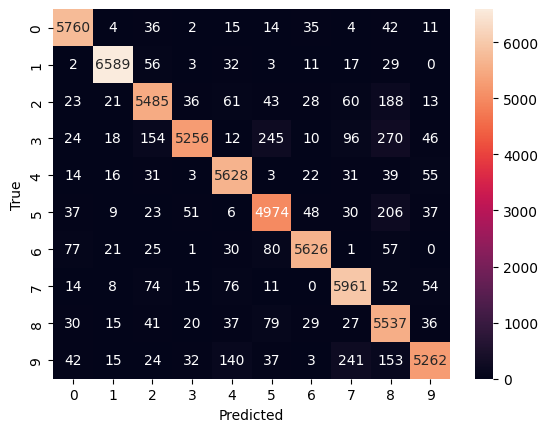

0.9346333333333333

In [54]:
# Evaluate after Task 1
print("Evaluation after Training Linear Layers Only:")
evaluate_model(model, mnist_loader)

In [55]:
# --------------------- TASK 2 ---------------------
for i, param in enumerate(model.parameters()):
    if i < 5:  # Freeze first 5 layers
        param.requires_grad = False
    else:
        param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

print("\nTraining with Initial Layers Frozen:")
train_model(model, mnist_loader, mnist_loader, criterion, optimizer)




Training with Initial Layers Frozen:
Epoch [1/10], Loss: 0.1078, Train Acc: 0.9710
Epoch [2/10], Loss: 0.0412, Train Acc: 0.9875
Epoch [3/10], Loss: 0.0325, Train Acc: 0.9902
Epoch [4/10], Loss: 0.0263, Train Acc: 0.9924
Epoch [5/10], Loss: 0.0242, Train Acc: 0.9930
Epoch [6/10], Loss: 0.0197, Train Acc: 0.9939
Epoch [7/10], Loss: 0.0157, Train Acc: 0.9951
Epoch [8/10], Loss: 0.0158, Train Acc: 0.9951
Epoch [9/10], Loss: 0.0130, Train Acc: 0.9959
Epoch [10/10], Loss: 0.0128, Train Acc: 0.9962


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Evaluation after Freezing Initial Layers and Training Others:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5923
           1       1.00      1.00      1.00      6742
           2       1.00      1.00      1.00      5958
           3       1.00      1.00      1.00      6131
           4       1.00      1.00      1.00      5842
           5       1.00      1.00      1.00      5421
           6       1.00      1.00      1.00      5918
           7       1.00      1.00      1.00      6265
           8       1.00      1.00      1.00      5851
           9       1.00      1.00      1.00      5949

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



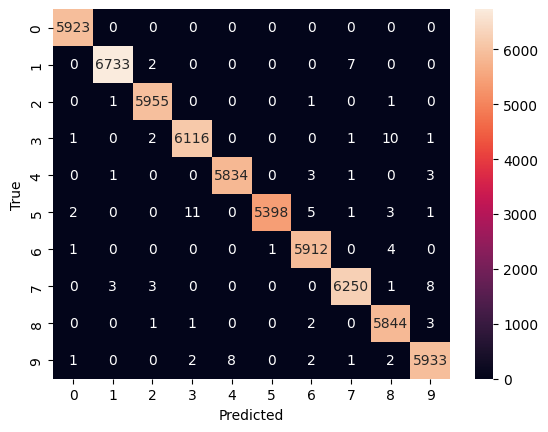

0.9983

In [56]:
# Evaluate after Task 2
print("Evaluation after Freezing Initial Layers and Training Others:")
evaluate_model(model, mnist_loader)

In [57]:


# --------------------- TASK 3 ---------------------
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers

optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Smaller LR for fine-tuning

print("\nFine-tuning Entire Model:")
train_model(model, mnist_loader, mnist_loader, criterion, optimizer)




Fine-tuning Entire Model:
Epoch [1/10], Loss: 0.0029, Train Acc: 0.9990
Epoch [2/10], Loss: 0.0009, Train Acc: 0.9998
Epoch [3/10], Loss: 0.0005, Train Acc: 0.9999
Epoch [4/10], Loss: 0.0007, Train Acc: 0.9998
Epoch [5/10], Loss: 0.0002, Train Acc: 1.0000
Epoch [6/10], Loss: 0.0004, Train Acc: 0.9999
Epoch [7/10], Loss: 0.0002, Train Acc: 1.0000
Epoch [8/10], Loss: 0.0001, Train Acc: 1.0000
Epoch [9/10], Loss: 0.0004, Train Acc: 0.9998
Epoch [10/10], Loss: 0.0001, Train Acc: 1.0000


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Evaluation after Fine-tuning the Entire Network:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5923
           1       1.00      1.00      1.00      6742
           2       1.00      1.00      1.00      5958
           3       1.00      1.00      1.00      6131
           4       1.00      1.00      1.00      5842
           5       1.00      1.00      1.00      5421
           6       1.00      1.00      1.00      5918
           7       1.00      1.00      1.00      6265
           8       1.00      1.00      1.00      5851
           9       1.00      1.00      1.00      5949

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



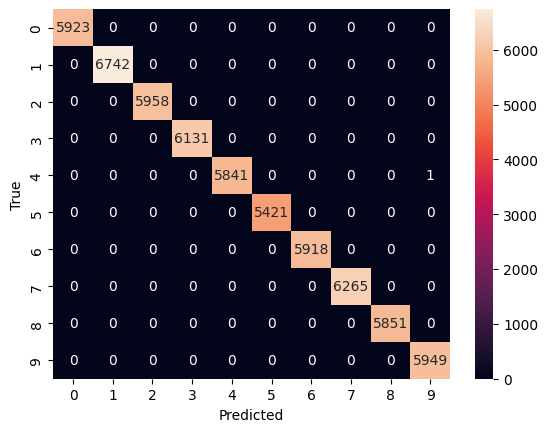

0.9999833333333333

In [58]:
# Final Evaluation
print("Evaluation after Fine-tuning the Entire Network:")
evaluate_model(model, mnist_loader)